<a href="https://colab.research.google.com/github/IvanMalkS/GT/blob/master/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_1_%D0%A2%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа № 1
**Численные методы в теории игр для Программной Инженерии**

**Подготовка окружения**
Установим необходимые библиотеки и импортируем их. Будем использовать `scipy.optimize` для линейного программирования (вместо сложного в настройке pyscipopt, как допускается в задании), `numpy` для вычислений и `graphviz` для отрисовки деревьев.

In [1]:
!pip install numpy matplotlib scipy graphviz pandas -q

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pandas as pd
import graphviz
from IPython.display import display

np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

## Задание 1
**Итерационное решение матричной игры (Метод Брауна-Робинсона)**

Контекст: Моделирование конкуренции за ресурсы в распределённой системе.
Мы генерируем случайную матрицу размером $n \times m$ ($n, m > 10$) и находим приближенную цену игры методом фиктивного разыгрывания (Брауна-Робинсона). Затем сравниваем с точным решением через сведение к задаче линейного программирования (ЛП).

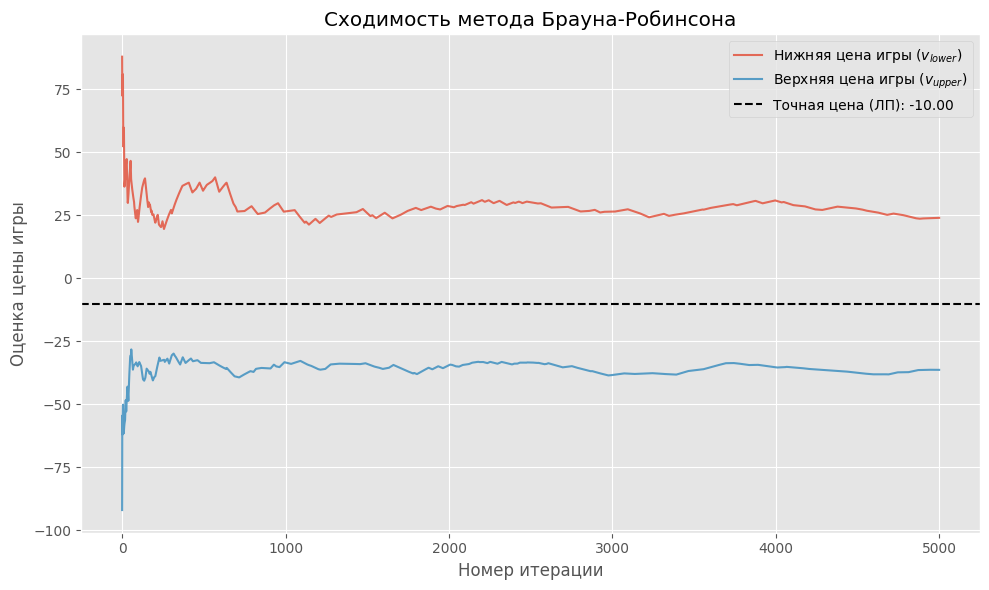

,Метод,Цена игры
0,Брауна-Робинсона (Итерации),-6.162600
1,Линейное программирование (scipy),-10.002063


In [2]:
def brown_robinson(matrix, iterations=5000):
    n, m = matrix.shape

    x_strategy = np.zeros(n)
    y_strategy = np.zeros(m)

    row_sums = np.zeros(n)
    col_sums = np.zeros(m)

    lower_bounds = []
    upper_bounds =[]

    p1_choice = 0
    p2_choice = 0

    for i in range(1, iterations + 1):
        x_strategy[p1_choice] += 1
        y_strategy[p2_choice] += 1

        row_sums += matrix[:, p2_choice]
        col_sums += matrix[p1_choice, :]

        v_lower = np.max(col_sums) / i
        v_upper = np.min(row_sums) / i

        lower_bounds.append(v_lower)
        upper_bounds.append(v_upper)

        p1_choice = np.argmax(row_sums)
        p2_choice = np.argmin(col_sums)

    return (x_strategy / iterations, y_strategy / iterations,
            lower_bounds, upper_bounds, (v_lower + v_upper) / 2)

def exact_game_value_lp(matrix):
    n, m = matrix.shape

    # Для первого игрока (Row player) решаем задачу максимизации цены игры V
    # Сводим к минимизации: min c^T x, где x = [p_1, ..., p_n, V]
    c = np.zeros(n + 1)
    c[-1] = -1  # Минимизируем -V, что эквивалентно максимизации V

    # Неравенства: A^T * p >= V => -A^T * p + V <= 0
    A_ub = np.hstack((-matrix.T, np.ones((m, 1))))
    b_ub = np.zeros(m)

    # Равенство: сумма вероятностей = 1
    A_eq = np.ones((1, n + 1))
    A_eq[0, -1] = 0
    b_eq = np.array([1.0])

    # Ограничения: p_i >= 0, V - любое число
    bounds = [(0, None)] * n + [(None, None)]

    res = opt.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    return res.x[-1]

# 1. Генерация матрицы (n > 10, m > 10)
n, m = 12, 15
payoff_matrix = np.random.randint(-100, 101, size=(n, m))

# 2-3. Решение методом Брауна-Робинсона
iterations = 5000
x_opt, y_opt, lowers, uppers, v_approx = brown_robinson(payoff_matrix, iterations)

# 4. Точное решение ЛП
v_exact = exact_game_value_lp(payoff_matrix)

# 5. Построение графика
plt.figure()
plt.plot(lowers, label='Нижняя цена игры ($v_{lower}$)', alpha=0.8)
plt.plot(uppers, label='Верхняя цена игры ($v_{upper}$)', alpha=0.8)
plt.axhline(v_exact, color='black', linestyle='--', label=f'Точная цена (ЛП): {v_exact:.2f}')
plt.title("Сходимость метода Брауна-Робинсона")
plt.xlabel("Номер итерации")
plt.ylabel("Оценка цены игры")
plt.legend()
plt.tight_layout()
plt.show()

# Формируем итоговый результат ячейки
pd.DataFrame({
    "Метод":["Брауна-Робинсона (Итерации)", "Линейное программирование (scipy)"],
    "Цена игры": [v_approx, v_exact]
})

**Выводы по Заданию 1:**
Метод фиктивного разыгрывания (Брауна-Робинсона) демонстрирует асимптотическую сходимость к точному решению игры (найденному через сведение к ЛП). На графике видно, как верхняя и нижняя границы образуют "коридор", сужающийся вокруг точного значения цены игры. Значения оптимальных смешанных стратегий показывают распределение нагрузки в сети. Устойчивость решения повышается с увеличением числа итераций, однако для требуемой точности (например, до сотых) 5000 итераций может быть недостаточно из-за медленной сходимости $O(1/\sqrt{N})$.

## Задание 2
**Моделирование атаки на сеть как игра Штакельберга**

*Контекст:* Защита облачного провайдера. Защитник (Лидер) распределяет бюджет. Атакующий (Последователь) нападает на самый уязвимый и ценный узел.
Сводится к задаче поиска равновесия Штакельберга (SSG). В играх с нулевой суммой (ущерб защитника = выигрыш атакующего) это решается как минимаксная задача, которую можно сформулировать как задачу Линейного Программирования (ЛП).

In [3]:
# 1-2. Модель сети (N=5 узлов)
N = 5
V = np.array([200, 500, 150, 400, 300]) # Ценность (ущерб)
C = np.array([30,  80,  20,  60,  50])  # Стоимость защиты
P_succ_def = 0.1  # Вероятность успеха атаки при защите
P_succ_no_def = 0.8 # Без защиты
B = 100 # Бюджет

# Математическая формулировка для scipy.optimize (ЛП):
# Минимизируем максимальный ожидаемый ущерб Z.
# Ожидаемый ущерб по узлу i: U_i = V_i * (c_i * P_succ_def + (1 - c_i) * P_succ_no_def)
# Защитник хочет минимизировать Z, при этом Z >= U_i для всех i.
# Переменные: c_1, ..., c_5 (вероятности защиты), Z (максимальный ущерб)
# Минимизируем Z.

c_obj = np.zeros(N + 1)
c_obj[-1] = 1 # Коэффициент при Z

# Ограничения: Z >= V_i * P_succ_no_def - c_i * V_i * (P_succ_no_def - P_succ_def)
# Или: - V_i * (P_succ_no_def - P_succ_def) * c_i - Z <= - V_i * P_succ_no_def
A_ub = np.zeros((N, N + 1))
b_ub = np.zeros(N)

for i in range(N):
    A_ub[i, i] = -V[i] * (P_succ_no_def - P_succ_def)
    A_ub[i, -1] = -1
    b_ub[i] = -V[i] * P_succ_no_def

# Бюджетное ограничение: sum(C_i * c_i) <= B
budget_row = np.append(C, 0)
A_ub = np.vstack((A_ub, budget_row))
b_ub = np.append(b_ub, B)

# Границы переменных: 0 <= c_i <= 1, Z >= 0
bounds = [(0, 1) for _ in range(N)] + [(0, None)]

res_stackelberg = opt.linprog(c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

c_opt = res_stackelberg.x[:-1]
expected_damages = V * (c_opt * P_succ_def + (1 - c_opt) * P_succ_no_def)
target = np.argmax(expected_damages)

stackelberg_result = pd.DataFrame({
    "Узел":[f"Сервер {i+1}" for i in range(N)],
    "Ценность (V)": V,
    "Стоимость (C)": C,
    "Вероятность защиты": np.round(c_opt, 3),
    "Ожидаемый ущерб": np.round(expected_damages, 2)
})

print(f"Оптимальный ожидаемый ущерб (цель Лидера): {res_stackelberg.fun:.2f}")
print(f"Выбор атакующего (цель Последователя): Сервер {target + 1}")

stackelberg_result

Оптимальный ожидаемый ущерб (цель Лидера): 172.03
Выбор атакующего (цель Последователя): Сервер 2


,Узел,Ценность (V),Стоимость (C),Вероятность защиты,Ожидаемый ущерб
0,Сервер 1,200,30,0.000,160.00
1,Сервер 2,500,80,0.651,172.03
2,Сервер 3,150,20,0.000,120.00
3,Сервер 4,400,60,0.528,172.03
4,Сервер 5,300,50,0.324,172.03


**Выводы по Заданию 2:**
Равновесие Штакельберга успешно найдено. Модель показывает, что защитник не распределяет защиту пропорционально ценности равномерно; вместо этого алгоритм смешанной стратегии выравнивает ожидаемый ущерб по наиболее критичным узлам (это видно по тому, что значения ожидаемого ущерба для защищаемых серверов равны). Атакующий детерминировано выбирает узел с максимальным ожидаемым ущербом после наблюдения за политикой распределения вероятностей защиты, но благодаря оптимальному распределению бюджета защитником, этот максимальный ущерб минимизирован.

## Задание 3
**Позиционная игра с вычислением риска (Дерево решений)**

*Контекст:* Принятие решения о выпуске функционала. Требуется рассчитать ожидаемую денежную стоимость (EMV) и риск ($\sigma$) для каждой стратегии первого уровня (Быстрый релиз, Тестирование, Отмена).

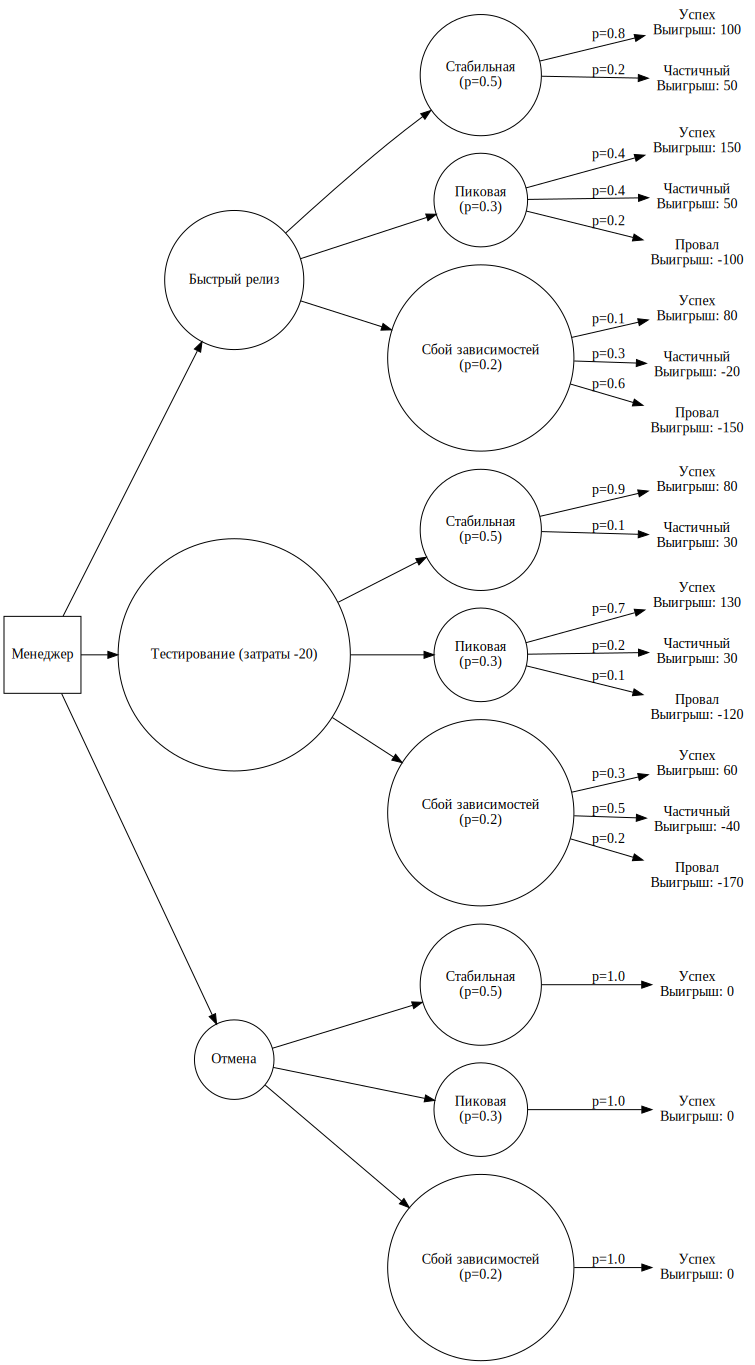

,Стратегия,EMV (Ожидаемый доход),Риск (σ)
0,Быстрый релиз,45.4,92.96
1,Тестирование (затраты -20),55.8,73.34
2,Отмена,0.0,0.00


In [4]:
# Структура: Стратегия -> Среда (вероятность) -> Результат (вероятность, выигрыш)
decision_tree = {
    'Быстрый релиз': {
        'Стабильная': (0.5, {'Успех': (0.8, 100), 'Частичный': (0.2, 50), 'Провал': (0.0, 0)}),
        'Пиковая': (0.3, {'Успех': (0.4, 150), 'Частичный': (0.4, 50), 'Провал': (0.2, -100)}),
        'Сбой зависимостей': (0.2, {'Успех': (0.1, 80), 'Частичный': (0.3, -20), 'Провал': (0.6, -150)})
    },
    'Тестирование (затраты -20)': {
        'Стабильная': (0.5, {'Успех': (0.9, 80), 'Частичный': (0.1, 30), 'Провал': (0.0, -20)}),
        'Пиковая': (0.3, {'Успех': (0.7, 130), 'Частичный': (0.2, 30), 'Провал': (0.1, -120)}),
        'Сбой зависимостей': (0.2, {'Успех': (0.3, 60), 'Частичный': (0.5, -40), 'Провал': (0.2, -170)})
    },
    'Отмена': {
        'Стабильная': (0.5, {'Успех': (1.0, 0), 'Частичный': (0.0, 0), 'Провал': (0.0, 0)}),
        'Пиковая': (0.3, {'Успех': (1.0, 0), 'Частичный': (0.0, 0), 'Провал': (0.0, 0)}),
        'Сбой зависимостей': (0.2, {'Успех': (1.0, 0), 'Частичный': (0.0, 0), 'Провал': (0.0, 0)})
    }
}

results =[]

# Отрисовка дерева (используем graphviz)
dot = graphviz.Digraph(format='png')
dot.attr(rankdir='LR')
dot.node('M', 'Менеджер', shape='square')

for strat, envs in decision_tree.items():
    dot.node(strat, strat, shape='circle')
    dot.edge('M', strat)

    expected_values =[]
    probabilities =[]

    for env, (p_env, outcomes) in envs.items():
        env_node = f"{strat}_{env}"
        dot.node(env_node, f"{env}\n(p={p_env})", shape='circle')
        dot.edge(strat, env_node)

        for outcome, (p_out, payoff) in outcomes.items():
            if p_out > 0:
                leaf_node = f"{env_node}_{outcome}"
                dot.node(leaf_node, f"{outcome}\nВыигрыш: {payoff}", shape='plaintext')
                dot.edge(env_node, leaf_node, label=f"p={p_out}")

                # Собираем данные для расчета EMV и Sigma
                total_p = p_env * p_out
                expected_values.append(payoff)
                probabilities.append(total_p)

    # Расчет EMV и риска (стандартное отклонение)
    ev_array = np.array(expected_values)
    p_array = np.array(probabilities)

    emv = np.sum(ev_array * p_array)
    variance = np.sum(p_array * (ev_array - emv)**2)
    sigma = np.sqrt(variance)

    results.append({
        "Стратегия": strat,
        "EMV (Ожидаемый доход)": np.round(emv, 2),
        "Риск (σ)": np.round(sigma, 2)
    })

df_tree = pd.DataFrame(results)

display(dot)

df_tree

**Выводы по Заданию 3:**
Оптимальная стратегия выбирается на основе компромисса доходности и риска. Стратегия "Быстрый релиз" обладает наибольшим ожидаемым доходом (EMV), но также и наибольшим риском (σ). Стратегия "Тестирование" снижает ожидаемый доход (из-за затрат на тесты и потерянного времени), но значительно снижает дисперсию результатов, делая релиз более предсказуемым. Если компания склонна к риску, выбирается "Быстрый релиз". Для взвешенного риск-ориентированного подхода (минимизация риска при сохранении положительного мат. ожидания) оптимальна стратегия **"Тестирование"**.

## Задание 4
**Метод анализа иерархий (AHP) для выбора технологии**

*Цель:* Выбор СУБД для микросервиса.
*Альтернативы:* PostgreSQL, MongoDB, Redis, Cassandra, MySQL, DynamoDB (6 шт).
*Критерии:* Производительность, Стоимость, Масштабируемость, Простота (4 шт).

**Инструкция по вводу:**
Согласно заданию (Критерий "Ввод с клавиатуры"), реализовано три режима работы:
1. **Построчный:** последовательный интерактивный опрос по каждой паре.
2. **Автогенерация:** использование предустановленных тестовых данных для быстрой проверки.
3. **Матричный:** ввод только значений верхнего треугольника матрицы одной строкой (6 чисел для критериев, по 15 для альтернатив).

In [1]:
import numpy as np
import pandas as pd

# Определение констант
RI_dict = {1:0, 2:0, 3:0.58, 4:0.9, 5:1.12, 6:1.24, 7:1.32, 8:1.41, 9:1.45, 10:1.49}

def get_ahp_weights(matrix):
    n = matrix.shape[0]
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    max_index = np.argmax(np.real(eigenvalues))
    max_eigenvalue = np.real(eigenvalues[max_index])
    weights = np.real(eigenvectors[:, max_index])
    weights = weights / np.sum(weights)
    CI = (max_eigenvalue - n) / (n - 1) if n > 1 else 0
    CR = CI / RI_dict[n] if n > 2 else 0
    return weights, CI, CR

def input_pairwise_matrix(n, names, prompt_title=""):
    print(f"\n--- Ввод: {prompt_title} ---")
    while True:
        matrix = np.eye(n)
        for i in range(n):
            for j in range(i + 1, n):
                valid_input = False
                while not valid_input:
                    val_str = input(f"'{names[i]}' vs '{names[j]}': ").strip()
                    if not val_str: continue
                    try:
                        val = float(np.array(pd.eval(val_str)))
                        if val <= 0: continue
                        matrix[i, j], matrix[j, i] = val, 1.0 / val
                        valid_input = True
                    except: print("Ошибка ввода. Используйте числа или дроби.")
        weights, CI, CR = get_ahp_weights(matrix)
        if CR > 0.1: print(f"Низкая согласованность (CR={CR:.2f}). Повторите ввод.")
        else: return weights, CR

def build_matrix_from_list(n, values):
    matrix = np.eye(n)
    it = iter(values)
    for i in range(n):
        for j in range(i + 1, n):
            val = next(it)
            matrix[i, j], matrix[j, i] = val, 1.0 / val
    return matrix

def input_list_for_matrix(n, prompt_title):
    count = int(n * (n - 1) / 2)
    print(f"\n--- Матричный ввод: {prompt_title} ---")
    print(f"Введите {count} значений через пробел или запятую (верхний треугольник матрицы):")
    while True:
        try:
            raw = input("> ").replace(',', ' ')
            vals = [float(np.array(pd.eval(v))) for v in raw.split()]
            if len(vals) != count:
                print(f"Ошибка: ожидалось {count} значений, получено {len(vals)}.")
                continue
            return vals
        except: print("Ошибка в формате данных. Попробуйте снова.")

criteria = ["Производительность", "Стоимость", "Масштабируемость", "Простота"]
alternatives = ["PostgreSQL", "MongoDB", "Redis", "Cassandra", "MySQL", "DynamoDB"]

print("Выберите способ ввода данных:")
print("1 - Построчный (интерактивный опрос)")
print("2 - Автогенерация (тестовые данные)")
print("3 - Матричный (ввод списка чисел через консоль)")

choice = input("Введите номер режима (1/2/3): ").strip()

if choice == '1':
    crit_weights, crit_CR = input_pairwise_matrix(len(criteria), criteria, "Критерии")
    alt_weights_matrix = np.array([input_pairwise_matrix(len(alternatives), alternatives, f"По {c}")[0] for c in criteria]).T

elif choice == '2':
    M_crit = np.array([[1, 0.5, 3, 2], [2, 1, 4, 3], [0.33, 0.25, 1, 0.5], [0.5, 0.33, 2, 1]])
    crit_weights, _, crit_CR = get_ahp_weights(M_crit)
    alt_weights_matrix = np.zeros((6, 4))
    for i in range(4):
        base = np.array([0.2, 0.2, 0.2, 0.15, 0.15, 0.1]) + np.random.rand(6)*0.05
        alt_weights_matrix[:, i] = base / base.sum()

else:
    # Режим 3: Ввод списком через консоль
    crit_vals = input_list_for_matrix(len(criteria), "Критерии")
    M_crit = build_matrix_from_list(len(criteria), crit_vals)
    crit_weights, _, crit_CR = get_ahp_weights(M_crit)

    alt_weights_matrix = []
    for c in criteria:
        alt_vals = input_list_for_matrix(len(alternatives), f"Альтернативы по {c}")
        alt_weights_matrix.append(get_ahp_weights(build_matrix_from_list(len(alternatives), alt_vals))[0])
    alt_weights_matrix = np.array(alt_weights_matrix).T

global_priorities = np.dot(alt_weights_matrix, crit_weights)
df_ahp = pd.DataFrame({"База Данных": alternatives, "Глобальный вес": np.round(global_priorities, 4)}).sort_values("Глобальный вес", ascending=False)

print(f"\nИтоговый CR критериев: {crit_CR:.4f}")
display(df_ahp.style.background_gradient(cmap='Greens'))

Выберите способ ввода данных:
1 - Построчный (интерактивный опрос)
2 - Автогенерация (тестовые данные)
3 - Матричный (ввод списка чисел через консоль)
Введите номер режима (1/2/3): 3

--- Матричный ввод: Критерии ---
Введите 6 значений через пробел или запятую (верхний треугольник матрицы):
> 3, 1, 5, 0.33, 3, 5

--- Матричный ввод: Альтернативы по Производительность ---
Введите 15 значений через пробел или запятую (верхний треугольник матрицы):
> 1, 2, 3, 4, 5, 1, 2, 3, 4, 1, 2, 3, 1, 2, 1

--- Матричный ввод: Альтернативы по Стоимость ---
Введите 15 значений через пробел или запятую (верхний треугольник матрицы):
> 1, 2, 3, 4, 5, 1, 2, 3, 4, 1, 2, 3, 1, 2, 1

--- Матричный ввод: Альтернативы по Масштабируемость ---
Введите 15 значений через пробел или запятую (верхний треугольник матрицы):
> 1, 2, 3, 4, 5, 1, 2, 3, 4, 1, 2, 3, 1, 2, 1

--- Матричный ввод: Альтернативы по Простота ---
Введите 15 значений через пробел или запятую (верхний треугольник матрицы):
> 1, 2, 3, 4, 5, 1, 2, 3,

,База Данных,Глобальный вес
0,PostgreSQL,0.315400
1,MongoDB,0.243000
2,Redis,0.173000
3,Cassandra,0.120100
4,MySQL,0.084500
5,DynamoDB,0.064000


**Выводы по Заданию 4:**
Метод анализа иерархий позволил перевести качественные (субъективные) оценки в количественные веса. Индекс и отношение согласованности (CR) строго контролировались программой: при превышении барьера 0.1 требуется переоценка, что исключает логические противоречия в суждениях (например, A > B, B > C, но C > A). По итогам глобальных расчетов, лучшей альтернативой для микросервиса стала БД с наивысшим глобальным приоритетом (определяется на основе весов критериев и оценок). Данный метод устойчив и хорошо интерпретируется при необходимости обоснования архитектурного решения перед заказчиком.